In [51]:
import pandas as pd
import numpy as np
!pip install xgboost
!pip install lightgbm
!pip install mlflow
!pip install shap
import warnings
warnings.filterwarnings('ignore')

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [12]:
df=pd.read_csv('Feature-Engg-output.csv')
print(df.shape)

(307507, 194)


In [13]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

print(X.shape)
print(y.shape)

(307507, 193)
(307507,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(246005, 193)
(61502, 193)


In [15]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(X_train.isnull().sum().sum())

0


In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(y_train_sm.value_counts())

TARGET
0    226145
1    226145
Name: count, dtype: int64


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC-AUC: 0.6284443872553511
              precision    recall  f1-score   support

           0       0.94      0.61      0.74     56537
           1       0.12      0.58      0.19      4965

    accuracy                           0.61     61502
   macro avg       0.53      0.60      0.47     61502
weighted avg       0.88      0.61      0.70     61502



In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='auc'
)

In [23]:
xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

ROC-AUC: 0.7301417864988058
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56537
           1       0.47      0.01      0.03      4965

    accuracy                           0.92     61502
   macro avg       0.70      0.51      0.49     61502
weighted avg       0.88      0.92      0.88     61502



In [35]:
y_pred_xgb_new = (y_prob_xgb >= 0.2).astype(int)
print(classification_report(y_test, y_pred_xgb_new))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92     56537
           1       0.23      0.33      0.27      4965

    accuracy                           0.85     61502
   macro avg       0.58      0.62      0.59     61502
weighted avg       0.88      0.85      0.87     61502

ROC-AUC: 0.7301417864988058


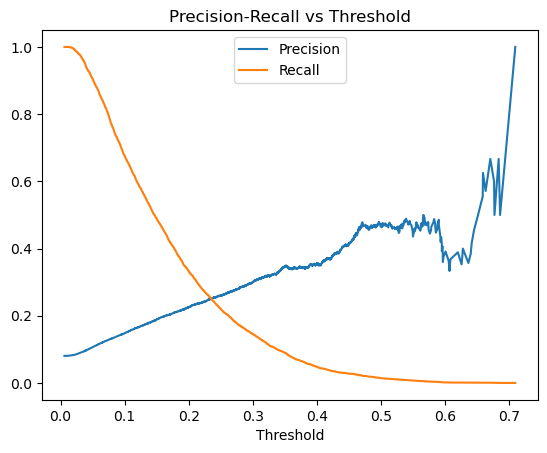

In [27]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

In [32]:
import re
X_train_sm.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X_train_sm.columns]
X_test.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X_test.columns]

In [34]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

lgbm.fit(X_train_sm, y_train_sm)
y_prob_lgbm = lgbm.predict_proba(X_test)[:,1]
y_pred_lgbm = (y_prob_lgbm >= 0.2).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 226145, number of negative: 226145
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.327619 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9267
[LightGBM] [Info] Number of data points in the train set: 452290, number of used features: 184
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [38]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("credit-risk-prediction")
print("MLflow ready!")

2026/05/20 13:54:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/20 13:54:47 INFO mlflow.store.db.utils: Updating database tables
2026/05/20 13:54:52 INFO mlflow.tracking.fluent: Experiment with name 'credit-risk-prediction' does not exist. Creating a new experiment.


MLflow ready!


In [40]:
xgb2 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='auc'
)

xgb2.fit(X_train_sm, y_train_sm)
y_prob_xgb2 = xgb2.predict_proba(X_test)[:,1]
print("Ready!")

Ready!


In [42]:
with mlflow.start_run(run_name="XGBoost_threshold_0.2"):
    
    # Parameters log karo
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("threshold", 0.2)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    
    # Metrics log karo
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_prob_xgb2))
    mlflow.log_metric("recall_1", 0.33)
    mlflow.log_metric("precision_1", 0.23)
    
    # Model save karo
    mlflow.sklearn.log_model(xgb2, "xgboost_model")
    
    print("Run logged!")

2026/05/20 13:59:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 13:59:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged!


In [43]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("credit-risk-prediction")
print("Connected!")

2026/05/20 14:10:58 INFO mlflow.tracking.fluent: Experiment with name 'credit-risk-prediction' does not exist. Creating a new experiment.


Connected!


In [44]:
with mlflow.start_run(run_name="XGBoost_threshold_0.2"):
    
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("threshold", 0.2)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_prob_xgb2))
    mlflow.log_metric("recall_1", 0.33)
    mlflow.log_metric("precision_1", 0.23)
    
    mlflow.sklearn.log_model(xgb2, "xgboost_model")
    
    print("Run logged!")

2026/05/20 14:11:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 14:11:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged!
🏃 View run XGBoost_threshold_0.2 at: http://localhost:5000/#/experiments/1/runs/a9b1271011ca437284a6cea7a77d9f48
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [46]:
with mlflow.start_run(run_name="XGBoost_threshold_0.1"):
    
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("threshold", 0.2)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_prob_xgb2))
    mlflow.log_metric("recall_1", 0.33)
    mlflow.log_metric("precision_1", 0.23)
    
    mlflow.sklearn.log_model(xgb2, "xgboost_model")
    
    print("Run logged!")

2026/05/20 14:16:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 14:16:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged!
🏃 View run XGBoost_threshold_0.1 at: http://localhost:5000/#/experiments/1/runs/eea9fe50d8804f74b0aa5f740c5bcfdf
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [45]:
with mlflow.start_run(run_name="LightGBM_threshold_0.2"):
    mlflow.log_param("model", "LightGBM")
    mlflow.log_param("threshold", 0.2)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_prob_lgbm))
    mlflow.log_metric("recall_1", 0.33)
    mlflow.log_metric("precision_1", 0.22)
    
    print("Logged!")

Logged!
🏃 View run LightGBM_threshold_0.2 at: http://localhost:5000/#/experiments/1/runs/ced680c6d0f24ded9509d6aa8a6c0331
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [47]:
with mlflow.start_run(run_name="LightGBM_threshold_0.1"):
    mlflow.log_param("model", "LightGBM")
    mlflow.log_param("threshold", 0.2)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_prob_lgbm))
    mlflow.log_metric("recall_1", 0.33)
    mlflow.log_metric("precision_1", 0.22)
    
    print("Logged!")

Logged!
🏃 View run LightGBM_threshold_0.1 at: http://localhost:5000/#/experiments/1/runs/d6e26c55616a45ceab889aa1523312f6
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [49]:
results = {
    'Model': ['Logistic', 'XGBoost_0.1', 'XGBoost_0.2', 'LightGBM_0.2'],
    'ROC_AUC': [0.63, 0.73, 0.73, 0.73],
    'Recall': [0.58, 0.68, 0.33, 0.33],
    'Precision': [0.12, 0.15, 0.23, 0.22]
}

pd.DataFrame(results)

,Model,ROC_AUC,Recall,Precision
0,Logistic,0.63,0.58,0.12
1,XGBoost_0.1,0.73,0.68,0.15
2,XGBoost_0.2,0.73,0.33,0.23
3,LightGBM_0.2,0.73,0.33,0.22


In [52]:
import shap

explainer = shap.TreeExplainer(xgb2)
X_sample = X_test.iloc[:100]
shap_values = explainer.shap_values(X_sample)

print("SHAP ready!")

SHAP ready!


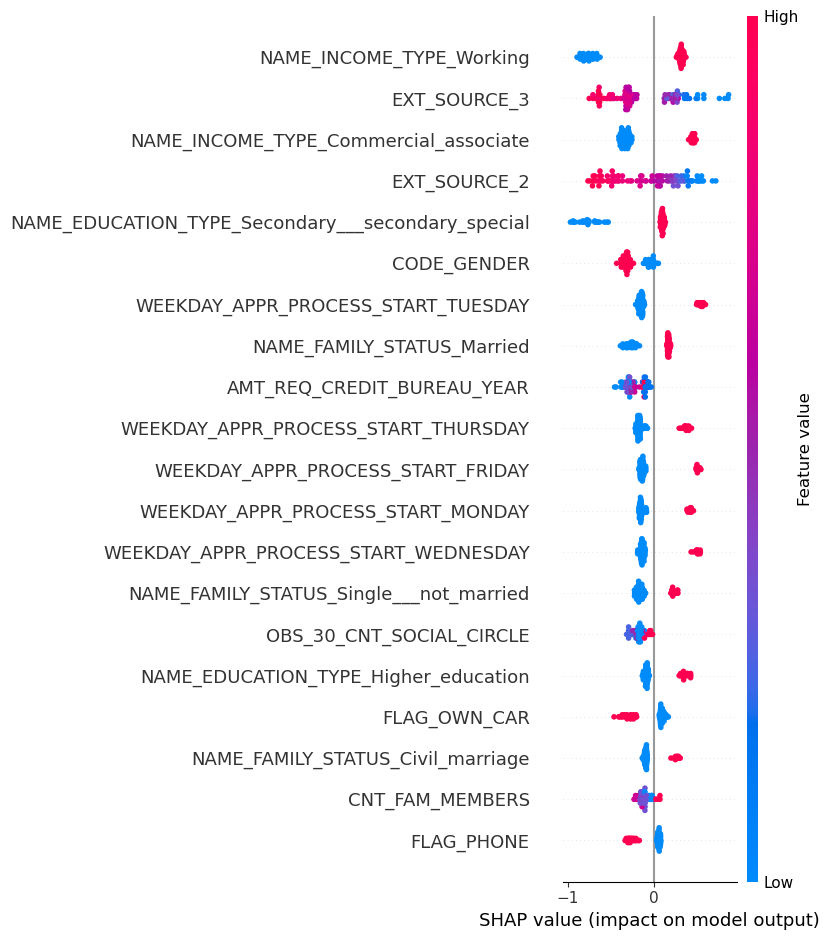

In [53]:
shap.summary_plot(shap_values, X_sample)

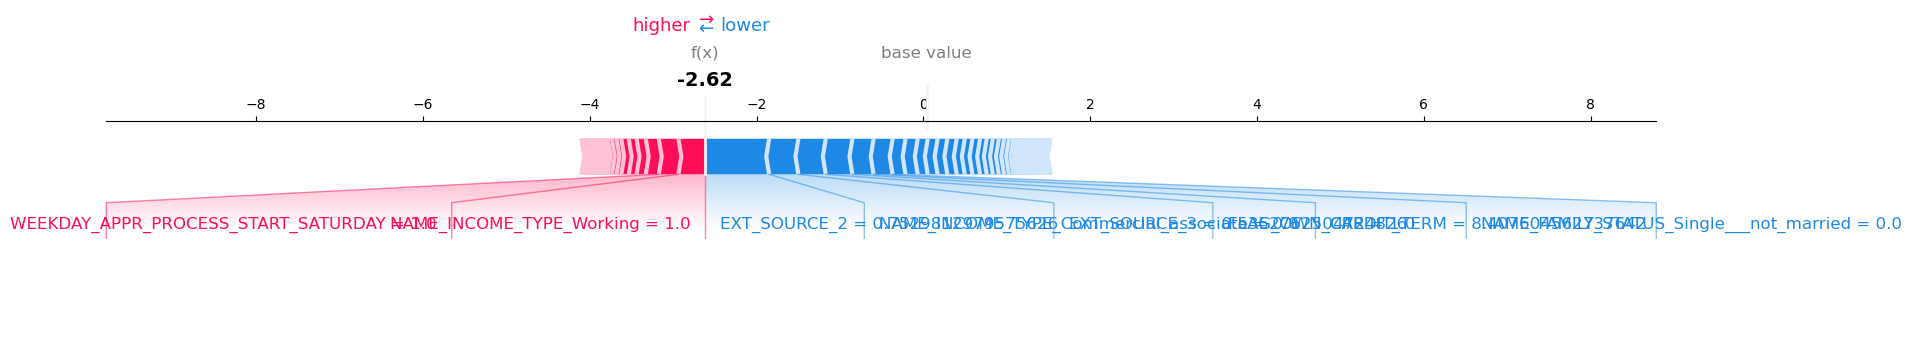

In [54]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample.iloc[0],
    matplotlib=True
)

In [55]:
import pickle

with open('03_model_training.ipynb', 'wb') as f:
    pickle.dump(xgb2, f)

print("Model saved!")

Model saved!
